# Perform NicheNet Analysis Starting from an AnnData Object (Wrapper)

In this notebook, you can learn how to perform a basic NicheNet analysis on an AnnData object containing single-cell expression data using the wrapper function `nichenet_seuratobj_aggregate`. This wrapper performs the same steps described in the step-by-step analysis notebook, but in a single function call.

As example expression data, we use mouse NICHE-seq data exploring intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after LCMV infection (Medaglia et al., 2017). We will focus on CD8 T cells as the receiver population.

## Prepare NicheNet Analysis

### Load packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt

import nichenetr as nn

In [2]:
sns.set_style('ticks')

### Read in NicheNet's networks

In [3]:
organism = "mouse"

lr_network = nn.load_lr_network(organism)
ligand_target_matrix = nn.load_ligand_target_matrix(organism)
weighted_networks = nn.load_weighted_networks(organism)

### Read in the expression data

In [4]:
adata = nn.load_seurat_obj()
adata = nn.alias_to_symbol_anndata(adata, "mouse")

adata

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'nGene', 'nUMI', 'orig.ident', 'aggregate', 'res.0.6', 'celltype', 'nCount_RNA', 'nFeature_RNA'
    obsm: 'X_cca', 'X_cca_aligned', 'X_pca', 'X_tsne'
    layers: 'data'

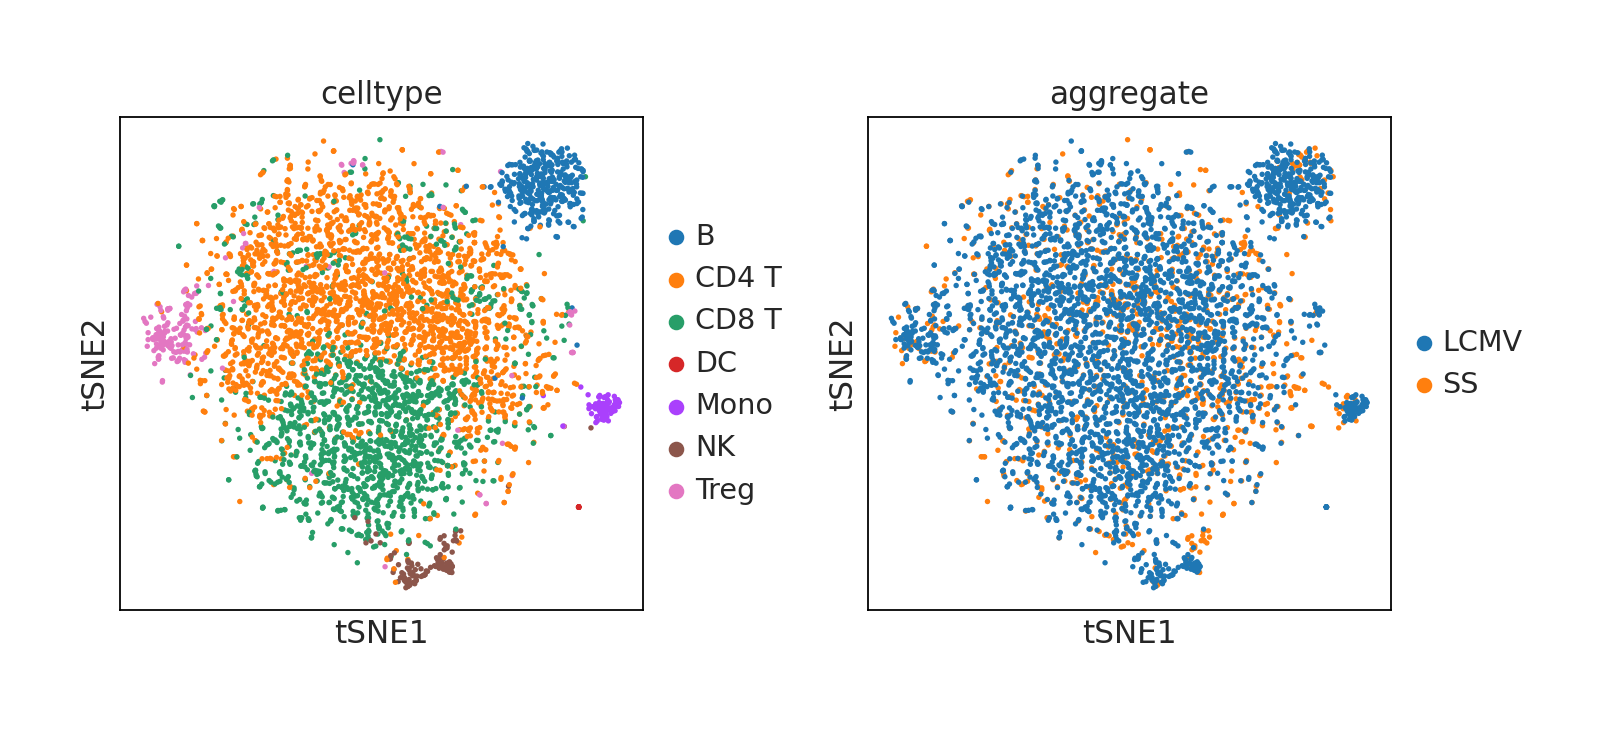

In [5]:
# Visualize cell populations
sc.set_figure_params(figsize=(4, 4))
sc.pl.tsne(adata, color=["celltype", "aggregate"], wspace=.3)

In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Perform the NicheNet Analysis

### Sender-agnostic approach

For the sender-agnostic approach, the sender is set to `"undefined"`. The receiver is CD8 T cells, and the gene set of interest is the set of DE genes after LCMV infection.

In [8]:
nichenet_output_agnostic = nn.nichenet_seuratobj_aggregate(
    receiver="CD8 T",
    adata=adata,
    sender="undefined",
    condition_col="aggregate",
    condition_oi="LCMV",
    condition_ref="SS",
    celltype_col="celltype",
    expression_pct=0.05,
    ligand_target_matrix=ligand_target_matrix,
    lr_network=lr_network,
    weighted_networks=weighted_networks,
)

Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Generate visualization figures


### Sender-focused approach

Provide one or more sender cell populations:

In [9]:
nichenet_output = nn.nichenet_seuratobj_aggregate(
    receiver="CD8 T",
    adata=adata,
    sender=["CD4 T", "Treg", "Mono", "NK", "B", "DC"],
    condition_col="aggregate",
    condition_oi="LCMV",
    condition_ref="SS",
    celltype_col="celltype",
    expression_pct=0.05,
    ligand_target_matrix=ligand_target_matrix,
    lr_network=lr_network,
    weighted_networks=weighted_networks,
)

Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells
Generate visualization figures


### Interpret the NicheNet analysis output

We investigate the output of the sender-focused approach.

In [10]:
print("Output keys:", list(nichenet_output.keys()))

Output keys: ['ligand_activities', 'top_ligands', 'top_targets', 'top_receptors', 'ligand_target_matrix', 'ligand_target_df', 'ligand_receptor_matrix', 'ligand_receptor_df', 'ligand_receptor_heatmap', 'ligand_target_heatmap', 'ligand_expression_dotplot', 'ligand_differential_expression_heatmap', 'ligand_activity_target_heatmap', 'geneset_oi', 'background_expressed_genes']


#### Ligand activity analysis results

In [11]:
nichenet_output["ligand_activities"]

,test_ligand,auroc,aupr,aupr_corrected,pearson,rank
79,Il27,0.660455,0.336028,0.265257,0.399405,1.0
35,Ebi3,0.645723,0.231384,0.160613,0.225343,2.0
117,Tnf,0.644703,0.172822,0.102051,0.206340,3.0
100,Ptprc,0.647816,0.172357,0.101586,0.148112,4.0
124,Vsig10,0.628952,0.167260,0.096489,0.143684,5.0
...,...,...,...,...,...,...
92,Mif,0.570627,0.087983,0.017212,-0.003737,123.0
74,Igf1,0.562625,0.086149,0.015378,0.012095,124.0
84,Lfng,0.552130,0.085704,0.014933,0.020394,125.0
43,Furin,0.556045,0.084720,0.013949,-0.015071,126.0


In [12]:
# Top 30 ligands
print(nichenet_output["top_ligands"])

['Il27', 'Ebi3', 'Tnf', 'Ptprc', 'Vsig10', 'H2-Eb1', 'H2-M3', 'Clcf1', 'H2-T24', 'H2-T10', 'H2-T22', 'H2-T-ps', 'H2-M2', 'H2-T23', 'H2-Oa', 'App', 'H2-K1', 'H2-Q6', 'H2-Q4', 'H2-Q7', 'H2-D1', 'Siglech', 'Sirpa', 'Il18bp', 'Siglec1', 'Ccl5', 'Ccl22', 'Cd48', 'Cd320', 'Selplg']


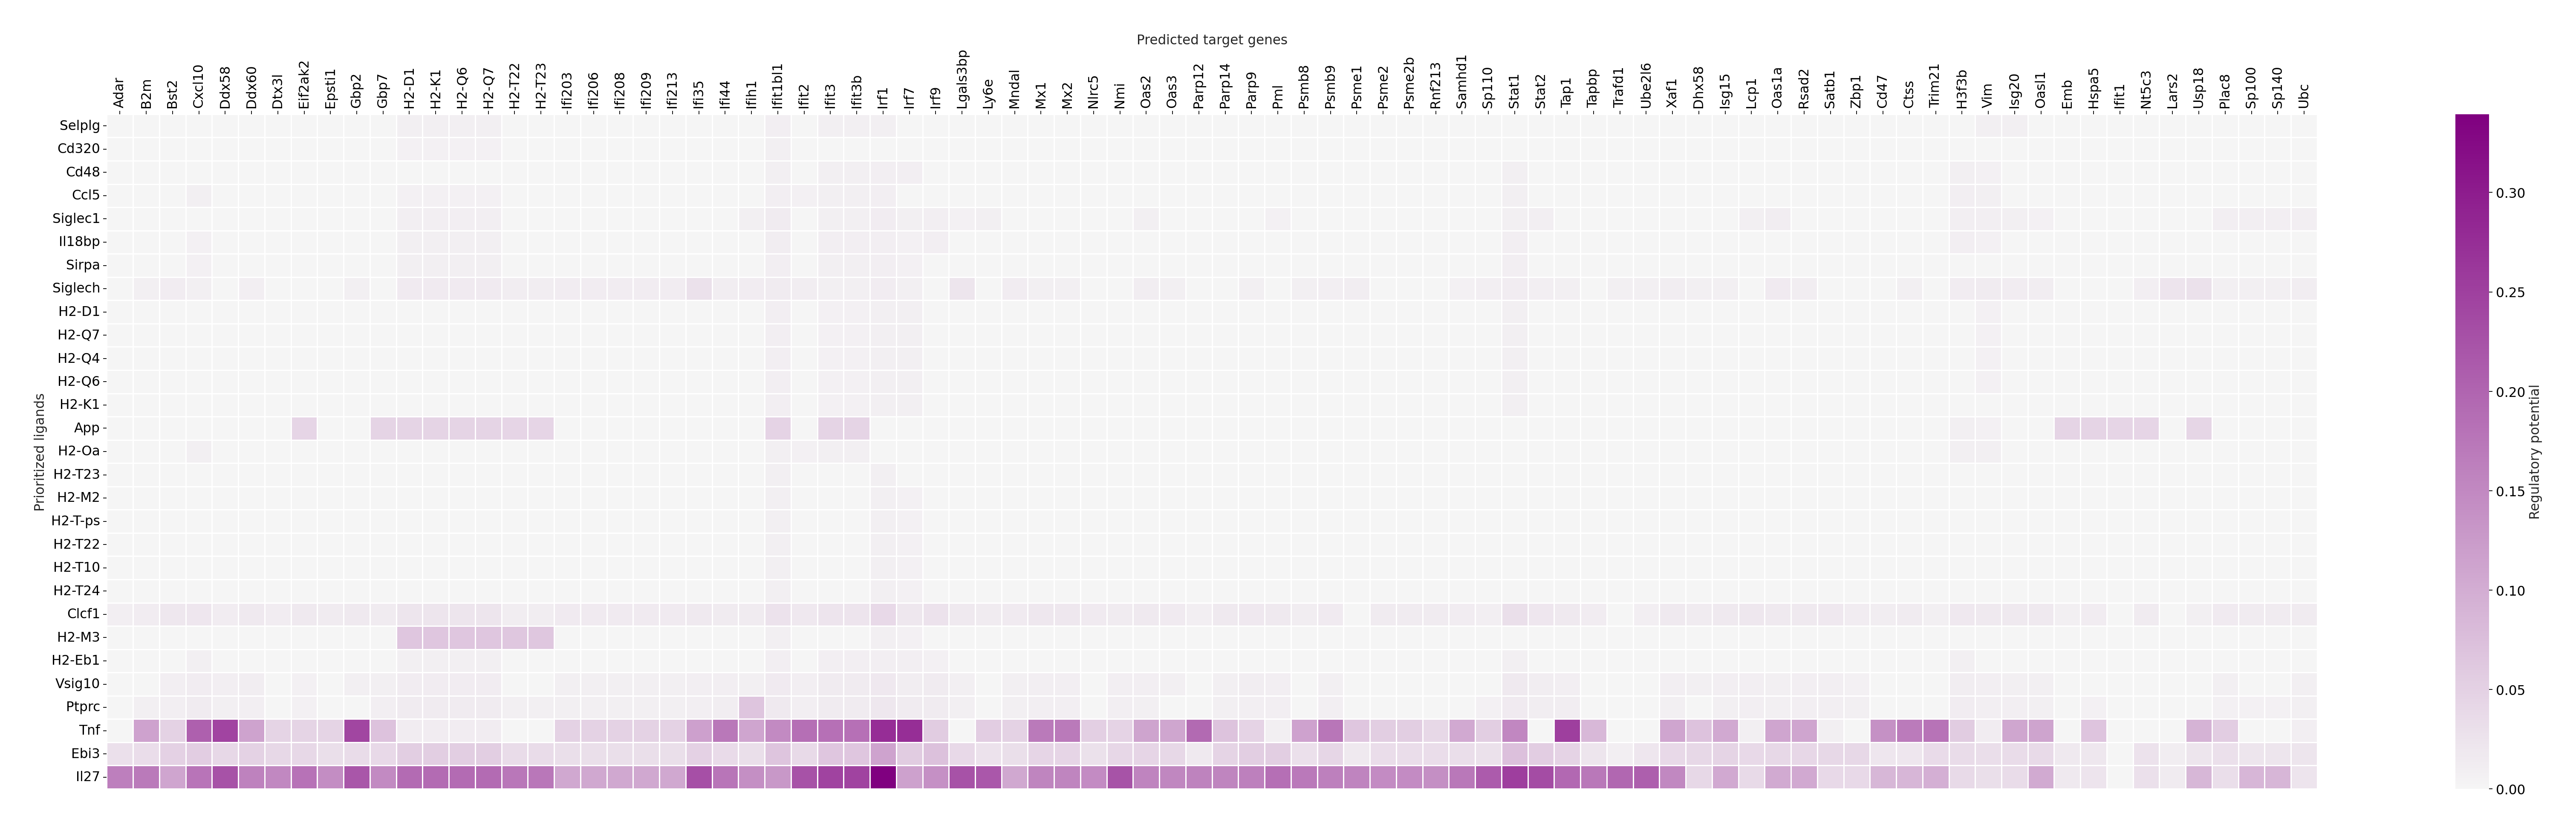

In [13]:
# Ligand-target heatmap
nichenet_output["ligand_target_heatmap"]

In [14]:
# Ligand-target links as a DataFrame
nichenet_output["ligand_target_df"].head(10)

,ligand,target,weight
0,Il27,Adar,0.163348
1,Il27,B2m,0.169988
2,Il27,Bst2,0.111081
3,Il27,Cxcl10,0.177837
4,Il27,Ddx58,0.226502
5,Il27,Ddx60,0.159677
6,Il27,Dtx3l,0.150134
7,Il27,Eif2ak2,0.180722
8,Il27,Epsti1,0.144292
9,Il27,Gbp2,0.220269


In [15]:
# Top targets
nichenet_output["top_targets"][:20]

['Adar',
 'B2m',
 'Bst2',
 'Cxcl10',
 'Ddx58',
 'Ddx60',
 'Dtx3l',
 'Eif2ak2',
 'Epsti1',
 'Gbp2',
 'Gbp7',
 'H2-D1',
 'H2-K1',
 'H2-Q6',
 'H2-Q7',
 'H2-T22',
 'H2-T23',
 'Ifi203',
 'Ifi206',
 'Ifi208']

#### Inferred ligand-receptor interactions

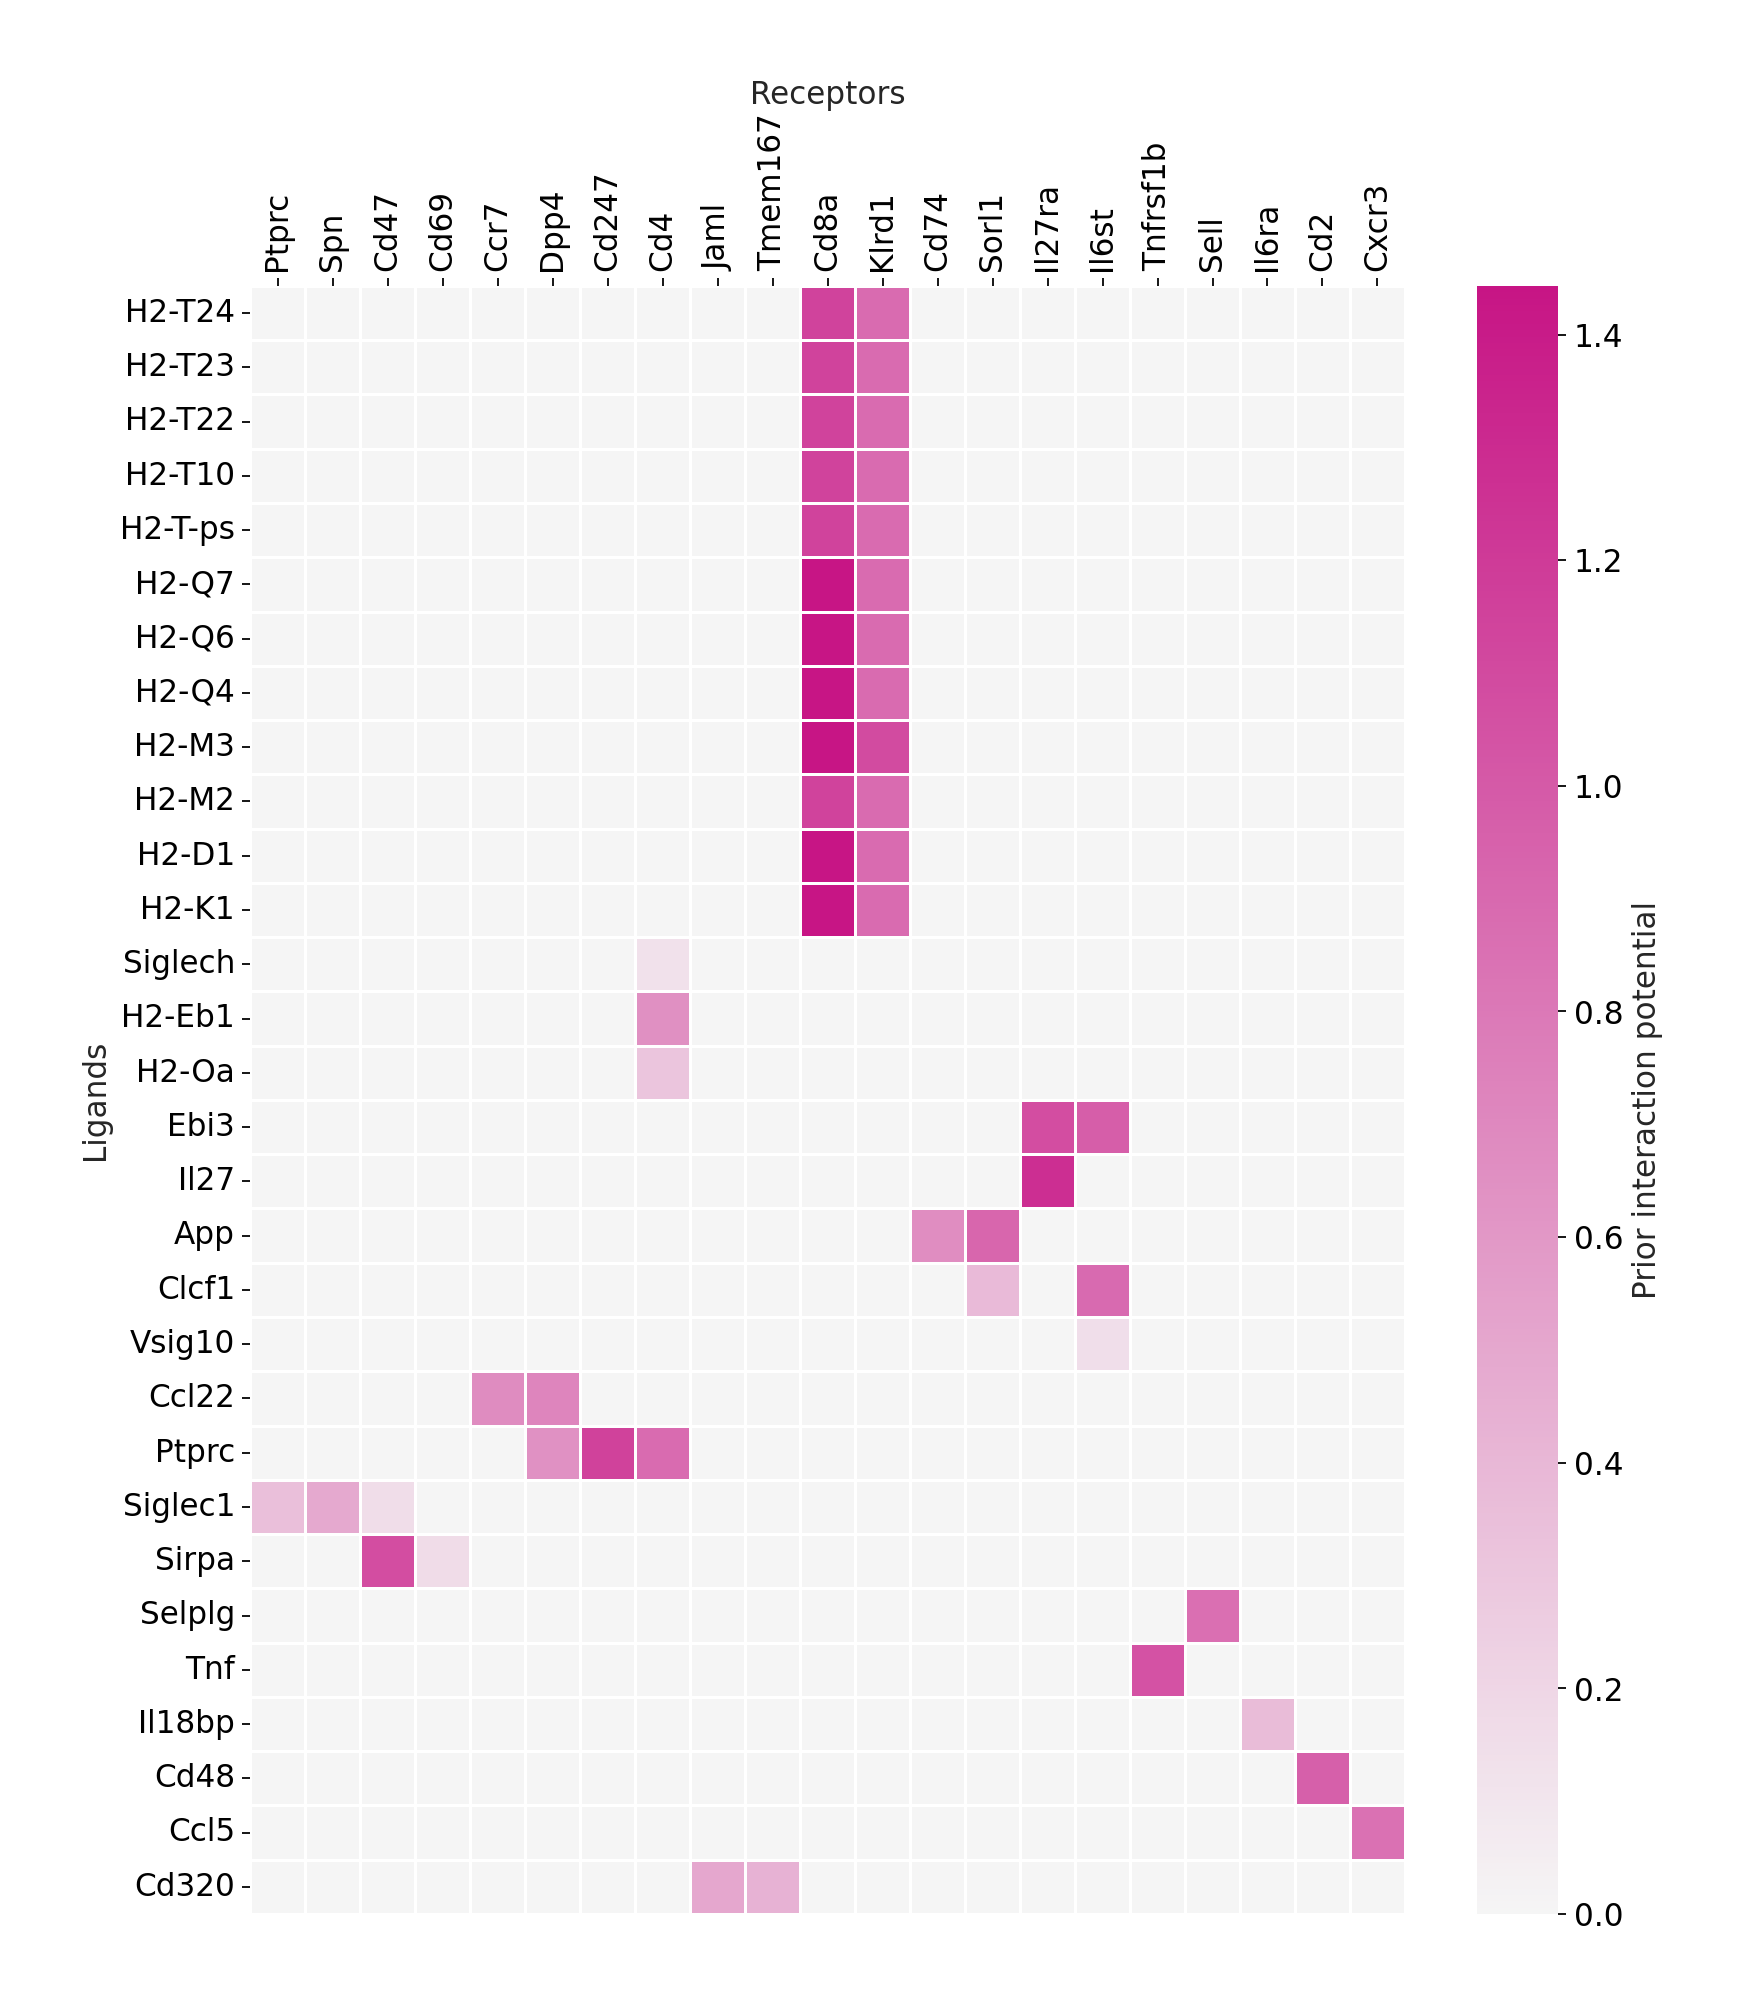

In [16]:
# Ligand-receptor heatmap
nichenet_output["ligand_receptor_heatmap"]

In [17]:
# Ligand-receptor links as a DataFrame
nichenet_output["ligand_receptor_df"].head(10)

,ligand,receptor,weight
324,App,Cd74,0.670218
332,App,Sorl1,0.921846
653,Ccl22,Ccr7,0.679269
654,Ccl22,Dpp4,0.717389
702,Ccl5,Cxcr3,0.848297
822,Cd320,Jaml,0.507248
826,Cd320,Tmem167,0.431637
861,Cd48,Cd2,0.963636
991,Clcf1,Il6st,0.892631
993,Clcf1,Sorl1,0.379626


In [18]:
# Top receptors
nichenet_output["top_receptors"]

['Cd74',
 'Sorl1',
 'Ccr7',
 'Dpp4',
 'Cxcr3',
 'Jaml',
 'Tmem167',
 'Cd2',
 'Il6st',
 'Il27ra',
 'Cd8a',
 'Klrd1',
 'Cd4',
 'Il6ra',
 'Cd247',
 'Sell',
 'Cd47',
 'Ptprc',
 'Spn',
 'Cd69',
 'Tnfrsf1b']

In [19]:
# Gene set and background genes
print(f"Gene set size: {len(nichenet_output['geneset_oi'])}")
print(f"Background genes: {len(nichenet_output['background_expressed_genes'])}")

Gene set size: 246
Background genes: 3476


### Results of the sender-agnostic approach

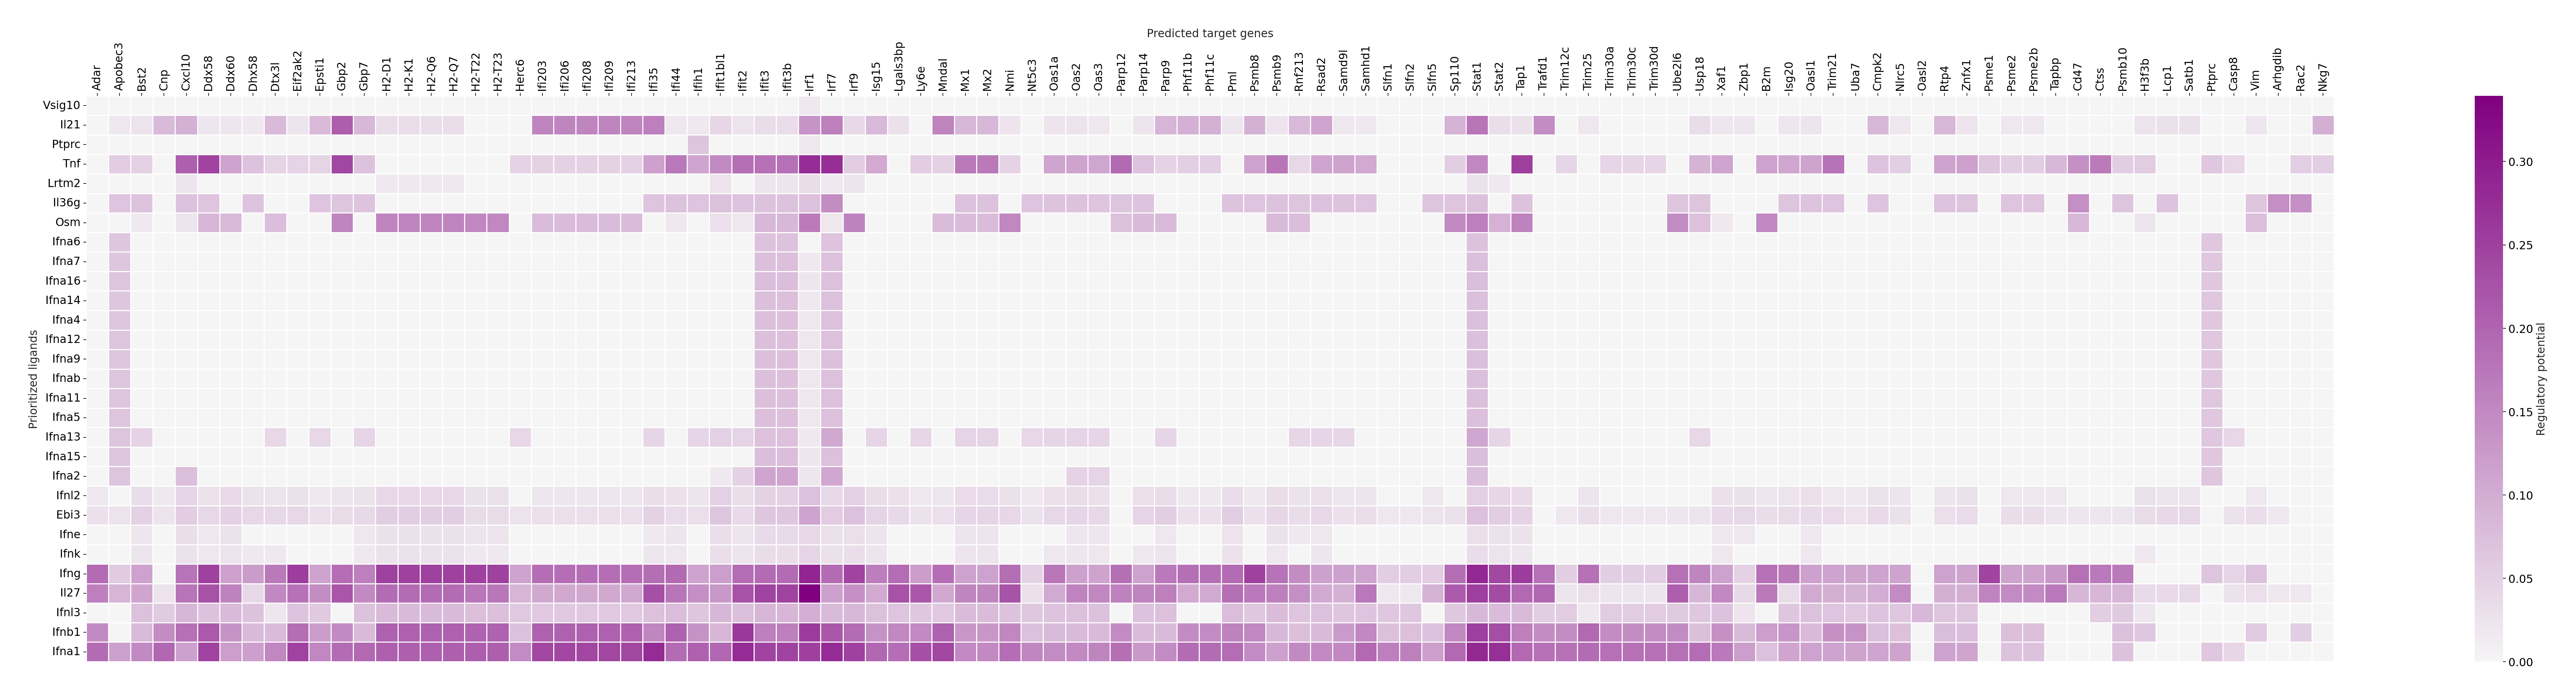

In [20]:
nichenet_output_agnostic["ligand_target_heatmap"]

### Running multiple NicheNet analyses on different receiver cell populations

You can run the analysis for every receiver cell type:

In [21]:
receiver_celltypes_oi = ["CD4 T", "CD8 T"]

nichenet_outputs = {}
for receiver_ct in receiver_celltypes_oi:
    nichenet_outputs[receiver_ct] = nn.nichenet_seuratobj_aggregate(
        receiver=receiver_ct,
        adata=adata,
        condition_col="aggregate",
        condition_oi="LCMV",
        condition_ref="SS",
        sender=["CD4 T", "Treg", "Mono", "NK", "B", "DC"],
        celltype_col="celltype",
        ligand_target_matrix=ligand_target_matrix,
        lr_network=lr_network,
        weighted_networks=weighted_networks,
    )

Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells
Generate visualization figures
Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells
Generate visualization figures


In [22]:
# Check common and cell-type-specific ligands
cd4_ligands_set = set(nichenet_outputs["CD4 T"]["top_ligands"])
cd8_ligands_set = set(nichenet_outputs["CD8 T"]["top_ligands"])

common_ligands = cd4_ligands_set & cd8_ligands_set
print("Common ligands:", sorted(common_ligands))
print("\nCD4 T-specific:", sorted(cd4_ligands_set - cd8_ligands_set))
print("\nCD8 T-specific:", sorted(cd8_ligands_set - cd4_ligands_set))

Common ligands: ['App', 'B2m', 'Btla', 'Ccl22', 'Cd48', 'Cd72', 'Ebi3', 'H2-D1', 'H2-DMb2', 'H2-K1', 'H2-M2', 'H2-M3', 'H2-Q4', 'H2-Q6', 'H2-Q7', 'H2-T10', 'H2-T22', 'H2-T23', 'Icam1', 'Itgb2', 'Ptprc', 'Selplg', 'Sirpa', 'Tgfb1']

CD4 T-specific: ['Fn1', 'H2-Eb1', 'H2-Oa', 'Hp', 'Il16', 'Vcan']

CD8 T-specific: ['Adam17', 'Cxcl10', 'Cxcl11', 'Cxcl9', 'H2-DMb1', 'Tgm2']
